## Limpeza e Padronização do Dataset

Prepara o dataset para os modelos de detecção de anomalias, tratando valores ausentes,
outliers extremos e variáveis categóricas.

Entrada:
- `data/processed/dataset_ml.csv` — 76.218 linhas × 27 features (gerado pelo NB05)

Problemas conhecidos a tratar:
1. **`dist_km_forn_orgao`** — 67,7% ausente (fornecedores fora de PE não têm coordenadas no municipios_pe.csv)
2. **`porte`, `cnae_fiscal`, `idade_empresa_anos`** — 24,6% ausente (erros de enriquecimento CNPJ no NB03)
3. **`opcao_pelo_mei`, `opcao_pelo_simples`** — 39,1% ausente (mesma origem)
4. **`desvio_preco_mediana`** — outliers extremos (max = 43.966 — winsorização no p99)
5. **Variáveis categóricas** (`modalidadeNome`, `porte`, `tipo_fornecedor`, `opcao_pelo_mei`, `opcao_pelo_simples`) — encoding para os modelos

Saída: `data/processed/dataset_ml_clean.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

os.makedirs('data/processed', exist_ok=True)
print('Setup OK')

Setup OK


### 1. Carrega e Inspeciona o Dataset

In [2]:
df = pd.read_csv('data/processed/dataset_ml.csv')

print(f'Shape: {df.shape}')
print(f'\nColunas ({len(df.columns)}):')
print(list(df.columns))
print('\nTipos de dados:')
print(df.dtypes)
df.head(3)

Shape: (76218, 27)

Colunas (27):
['orgaoEntidadeCnpj', 'anoCompraPncp', 'sequencialCompraPncp', 'numeroItem', 'cnpj_forn_norm', 'desvio_preco_mediana', 'ratio_preco_estimado', 'n_propostas_item', 'fornecedor_unico', 'ano', 'mes', 'trimestre', 'dia_semana', 'dias_para_eleicao', 'ano_eleitoral', 'pre_eleitoral_180d', 'dist_km_forn_orgao', 'fornecedor_fora_pe', 'tipo_fornecedor', 'idade_empresa_anos', 'empresa_nova', 'freq_forn_orgao', 'opcao_pelo_mei', 'opcao_pelo_simples', 'modalidadeNome', 'porte', 'cnae_fiscal']

Tipos de dados:
orgaoEntidadeCnpj         int64
anoCompraPncp             int64
sequencialCompraPncp      int64
numeroItem                int64
cnpj_forn_norm            int64
desvio_preco_mediana    float64
ratio_preco_estimado    float64
n_propostas_item          int64
fornecedor_unico          int64
ano                       int64
mes                       int64
trimestre                 int64
dia_semana                int64
dias_para_eleicao         int64
ano_eleitoral  

,orgaoEntidadeCnpj,anoCompraPncp,sequencialCompraPncp,numeroItem,cnpj_forn_norm,desvio_preco_mediana,ratio_preco_estimado,n_propostas_item,fornecedor_unico,ano,mes,trimestre,dia_semana,dias_para_eleicao,ano_eleitoral,pre_eleitoral_180d,dist_km_forn_orgao,fornecedor_fora_pe,tipo_fornecedor,idade_empresa_anos,empresa_nova,freq_forn_orgao,opcao_pelo_mei,opcao_pelo_simples,modalidadeNome,porte,cnae_fiscal
0,10260222000105,2023,61,1,40230669000194,-0.0461,1.0000,2,0,2023,7,3,3,451,0,0,0.0000,0,pessoa_juridica,2.5243,0,1,True,True,Inexigibilidade,MICRO EMPRESA,8230001.0000
1,402552000126,2022,331,1,33040635000171,0.3936,1.0000,2,0,2023,7,3,6,455,0,0,NaN,1,pessoa_juridica,50.1602,0,1,NaN,NaN,Inexigibilidade,DEMAIS,4645101.0000
2,10260222000105,2023,60,1,10474760456,0.0000,1.0000,1,1,2023,7,3,3,451,0,0,NaN,1,pessoa_fisica,NaN,0,1,NaN,NaN,Inexigibilidade,NaN,NaN


### 2. Análise de Valores Ausentes

Colunas com valores ausentes:

                      ausentes  pct (%)
dist_km_forn_orgao       51630  67.7000
opcao_pelo_mei           29803  39.1000
opcao_pelo_simples       29803  39.1000
idade_empresa_anos       18740  24.6000
porte                    18740  24.6000
cnae_fiscal              18740  24.6000
ratio_preco_estimado       830   1.1000
desvio_preco_mediana       640   0.8000


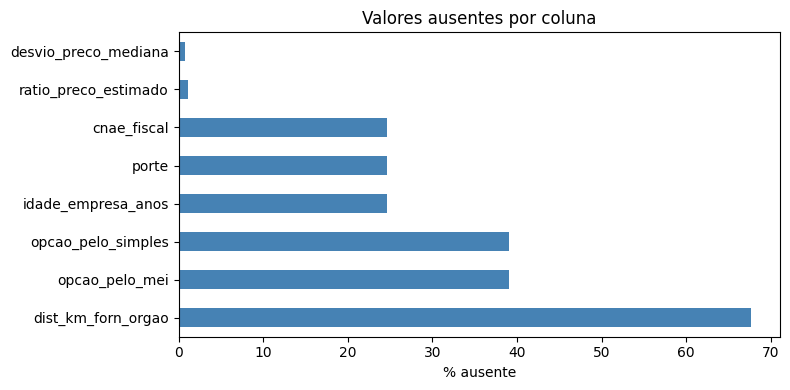

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

relatorio_missing = pd.DataFrame({
    'ausentes': missing,
    'pct (%)': missing_pct
}).query('ausentes > 0').sort_values('pct (%)', ascending=False)

print('Colunas com valores ausentes:\n')
print(relatorio_missing.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
relatorio_missing['pct (%)'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% ausente')
ax.set_title('Valores ausentes por coluna')
plt.tight_layout()
plt.show()

### 3. Tratamento: `dist_km_forn_orgao` (67,7% ausente)

A feature geográfica numérica tem alta taxa de ausência porque fornecedores de outros estados
não têm coordenadas no `municipios_pe.csv`. Estratégia: remover a coluna e manter
`fornecedor_fora_pe` (100% preenchida) como proxy binário da distância.

In [4]:
print(f'dist_km_forn_orgao — ausentes: {df["dist_km_forn_orgao"].isna().sum()} ({df["dist_km_forn_orgao"].isna().mean()*100:.1f}%)')
print(f'fornecedor_fora_pe — ausentes: {df["fornecedor_fora_pe"].isna().sum()} (proxy binário — 100% preenchido)')

df = df.drop(columns=['dist_km_forn_orgao'])

print('\n✓ dist_km_forn_orgao removida.')
print(f'Shape após remoção: {df.shape}')

dist_km_forn_orgao — ausentes: 51630 (67.7%)
fornecedor_fora_pe — ausentes: 0 (proxy binário — 100% preenchido)

✓ dist_km_forn_orgao removida.
Shape após remoção: (76218, 26)


### 4. Tratamento: Variáveis Derivadas do CNPJ (24,6%–39,1% ausente)

As features `porte`, `cnae_fiscal`, `idade_empresa_anos`, `opcao_pelo_mei` e `opcao_pelo_simples`
têm ausências provenientes dos erros de enriquecimento no NB03 (CPFs de pessoa física +
CNPJs inválidos/cancelados). Estratégia:
- `porte`: imputar com `'DESCONHECIDO'`
- `cnae_fiscal`: imputar com `-1` (código sentinela para "sem CNAE")
- `idade_empresa_anos`: imputar com a mediana do grupo `tipo_fornecedor`
- `opcao_pelo_mei` / `opcao_pelo_simples`: NaN → `False` (ausência = não optante ou pessoa física)

In [5]:
# porte
df['porte'] = df['porte'].fillna('DESCONHECIDO')
print('porte após imputação:')
print(df['porte'].value_counts())

# cnae_fiscal
df['cnae_fiscal'] = df['cnae_fiscal'].fillna(-1).astype(int)
print(f'\ncnae_fiscal — ausentes após imputação: {(df["cnae_fiscal"] == -1).sum()}')

# idade_empresa_anos — mediana por tipo_fornecedor
mediana_idade = df.groupby('tipo_fornecedor')['idade_empresa_anos'].transform('median')
df['idade_empresa_anos'] = df['idade_empresa_anos'].fillna(mediana_idade)
print(f'\nidade_empresa_anos — ausentes após imputação: {df["idade_empresa_anos"].isna().sum()}')
print(f'Mediana por tipo: {df.groupby("tipo_fornecedor")["idade_empresa_anos"].median().to_dict()}')

# opcao_pelo_mei e opcao_pelo_simples
# Valores originais são strings 'true'/'false' — normalizar e imputar
for col in ['opcao_pelo_mei', 'opcao_pelo_simples']:
    df[col] = df[col].map({'True': True, 'False': False, True: True, False: False}).fillna(False)
    print(f'{col} — distribuição: {df[col].value_counts().to_dict()}')

porte após imputação:
porte
MICRO EMPRESA               21597
EMPRESA DE PEQUENO PORTE    20264
DESCONHECIDO                18740
DEMAIS                      15617
Name: count, dtype: int64

cnae_fiscal — ausentes após imputação: 18740

idade_empresa_anos — ausentes após imputação: 0
Mediana por tipo: {'pessoa_fisica': 28.80492813141684, 'pessoa_juridica': 8.659822039698836}
opcao_pelo_mei — distribuição: {False: 75656, True: 562}
opcao_pelo_simples — distribuição: {False: 48536, True: 27682}


/var/folders/6t/_x8wq2ld5t54dlf3mhzwqt2h0000gp/T/ipykernel_17458/2085253971.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].map({'True': True, 'False': False, True: True, False: False}).fillna(False)
/var/folders/6t/_x8wq2ld5t54dlf3mhzwqt2h0000gp/T/ipykernel_17458/2085253971.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].map({'True': True, 'False': False, True: True, False: False}).fillna(False)


### 5. Tratamento de Outliers (`desvio_preco_mediana`)

A distribuição é fortemente assimétrica: 75% dos valores estão em 0, mas o máximo chega a
43.966 (sobrepreço de 4.396.647%). Esses valores extremos distorceriam os modelos baseados
em distância (LOF, One-Class SVM). Estratégia: winsorização no percentil 99 — valores acima
do p99 são substituídos pelo próprio p99.

Antes da winsorização:
count   75578.0000
mean        0.6148
std       159.9717
min        -1.0000
25%         0.0000
50%         0.0000
75%         0.0000
max     43966.4797
Name: desvio_preco_mediana, dtype: float64

Limites aplicados: p01 = -0.9009 | p99 = 0.8016

Após winsorização:
count   76218.0000
mean       -0.0029
std         0.1450
min        -0.9009
25%         0.0000
50%         0.0000
75%         0.0000
max         0.8016
Name: desvio_preco_mediana, dtype: float64

ratio_preco_estimado — p99 = 1.0000 | NaN imputados com 1.0


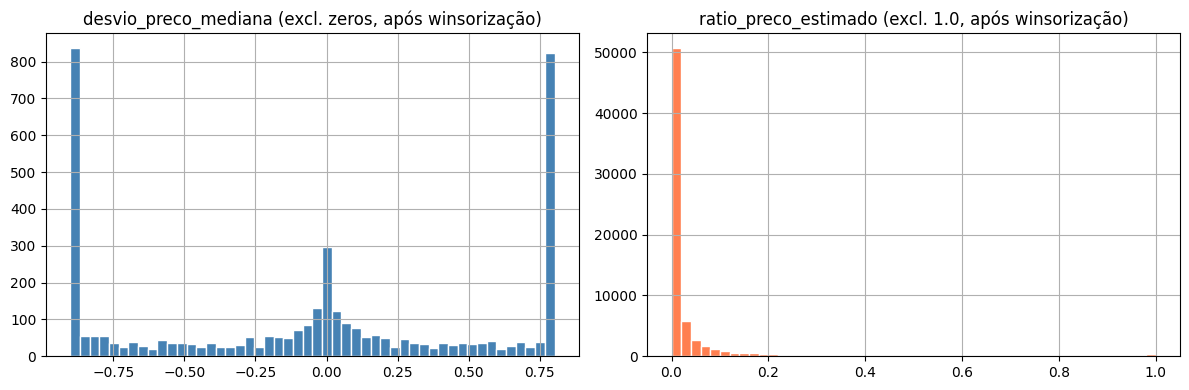

In [6]:
col = 'desvio_preco_mediana'

print('Antes da winsorização:')
print(df[col].describe())

# Imputa os 640 NaN com 0 (proposta no valor exato da mediana = sem desvio)
df[col] = df[col].fillna(0)

# Winsorização no p99
p99 = df[col].quantile(0.99)
p01 = df[col].quantile(0.01)
df[col] = df[col].clip(lower=p01, upper=p99)

print(f'\nLimites aplicados: p01 = {p01:.4f} | p99 = {p99:.4f}')
print('\nApós winsorização:')
print(df[col].describe())

# Mesmo tratamento para ratio_preco_estimado
col2 = 'ratio_preco_estimado'
df[col2] = df[col2].fillna(1.0)  # NaN → razão neutra
p99_r = df[col2].quantile(0.99)
df[col2] = df[col2].clip(upper=p99_r)
print(f'\nratio_preco_estimado — p99 = {p99_r:.4f} | NaN imputados com 1.0')

# Visualização da distribuição final
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[df['desvio_preco_mediana'] != 0]['desvio_preco_mediana'].hist(
    bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('desvio_preco_mediana (excl. zeros, após winsorização)')
df[df['ratio_preco_estimado'] != 1.0]['ratio_preco_estimado'].hist(
    bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('ratio_preco_estimado (excl. 1.0, após winsorização)')
plt.tight_layout()
plt.show()

### 6. Encoding de Variáveis Categóricas

Os modelos não supervisionados (Isolation Forest, LOF, One-Class SVM) requerem entrada
numérica. Estratégia por variável:
- **`tipo_fornecedor`**: binário — `pessoa_juridica` = 1, `pessoa_fisica` = 0
- **`opcao_pelo_mei`** / **`opcao_pelo_simples`**: booleano → inteiro (0/1)
- **`porte`**: ordinal por tamanho — `MICRO EMPRESA` = 1, `EMPRESA DE PEQUENO PORTE` = 2, `DEMAIS` = 3, `DESCONHECIDO` = 0
- **`modalidadeNome`**: label encoding (6 categorias)
- **`cnae_fiscal`**: já numérico (int) — mantido como está

In [7]:
# tipo_fornecedor → binário
df['tipo_fornecedor'] = df['tipo_fornecedor'].map({'pessoa_juridica': 1, 'pessoa_fisica': 0})
print('tipo_fornecedor:', df['tipo_fornecedor'].value_counts().to_dict())

# opcao_pelo_mei e opcao_pelo_simples → int
df['opcao_pelo_mei']    = df['opcao_pelo_mei'].astype(int)
df['opcao_pelo_simples'] = df['opcao_pelo_simples'].astype(int)

# porte → ordinal
porte_map = {
    'DESCONHECIDO':             0,
    'MICRO EMPRESA':            1,
    'EMPRESA DE PEQUENO PORTE': 2,
    'DEMAIS':                   3,
}
df['porte'] = df['porte'].map(porte_map)
print('porte (ordinal):', df['porte'].value_counts().sort_index().to_dict())

# modalidadeNome → label encoding
modalidade_cats = df['modalidadeNome'].astype('category')
print('\nmodalidadeNome — categorias:', dict(enumerate(modalidade_cats.cat.categories)))
df['modalidadeNome'] = modalidade_cats.cat.codes

print('\nEncoding concluído.')
print('Tipos após encoding:')
print(df[['tipo_fornecedor', 'opcao_pelo_mei', 'opcao_pelo_simples',
          'porte', 'modalidadeNome', 'cnae_fiscal']].dtypes)

tipo_fornecedor: {1: 69446, 0: 6772}
porte (ordinal): {0: 18740, 1: 21597, 2: 20264, 3: 15617}

modalidadeNome — categorias: {0: 'Concorrência - Eletrônica', 1: 'Concorrência - Presencial', 2: 'Dispensa', 3: 'Inexigibilidade', 4: 'Pregão - Eletrônico', 5: 'Pregão - Presencial'}

Encoding concluído.
Tipos após encoding:
tipo_fornecedor       int64
opcao_pelo_mei        int64
opcao_pelo_simples    int64
porte                 int64
modalidadeNome         int8
cnae_fiscal           int64
dtype: object


### 7. Validação Final

In [8]:
print(f'Shape final: {df.shape}')

missing_final = df.isnull().sum()
missing_final = missing_final[missing_final > 0]
if len(missing_final) == 0:
    print('✓ Sem valores ausentes remanescentes.')
else:
    print('⚠ Valores ausentes remanescentes:')
    print(missing_final)

non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f'\n⚠ Colunas não numéricas remanescentes: {non_numeric}')
else:
    print('✓ Todas as colunas são numéricas.')

print('\nEstatísticas descritivas do dataset limpo:')
df.describe()

Shape final: (76218, 26)
✓ Sem valores ausentes remanescentes.
✓ Todas as colunas são numéricas.

Estatísticas descritivas do dataset limpo:


,orgaoEntidadeCnpj,anoCompraPncp,sequencialCompraPncp,numeroItem,cnpj_forn_norm,desvio_preco_mediana,ratio_preco_estimado,n_propostas_item,fornecedor_unico,ano,mes,trimestre,dia_semana,dias_para_eleicao,ano_eleitoral,pre_eleitoral_180d,fornecedor_fora_pe,tipo_fornecedor,idade_empresa_anos,empresa_nova,freq_forn_orgao,opcao_pelo_mei,opcao_pelo_simples,modalidadeNome,porte,cnae_fiscal
count,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000,76218.0000
mean,8156091758816.7402,2023.6800,3682.1427,57.5519,26399928380265.6484,-0.0029,0.1295,1.4856,0.8974,2023.7233,7.4150,2.7957,2.0363,186.1541,0.7233,0.5910,0.6312,0.9111,13.1373,0.0684,3.2265,0.0074,0.3632,3.4851,1.4298,3684331.4535
std,9239763107972.7324,0.4812,5619.6788,84.3112,202284654555954.8750,0.1450,0.2909,2.9822,0.3035,0.4474,3.1213,1.0059,1.4312,155.3532,0.4474,0.4917,0.4825,0.2845,11.4510,0.2525,4.6790,0.0856,0.4809,0.8152,1.0708,2397285.4045
min,38166000105.0000,2022.0000,1.0000,1.0000,0.0000,-0.9009,0.0000,1.0000,0.0000,2023.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,-1.0000
25%,394452000103.0000,2023.0000,70.0000,5.0000,8778201000126.0000,0.0000,0.0014,1.0000,1.0000,2023.0000,5.0000,2.0000,1.0000,57.0000,0.0000,0.0000,0.0000,1.0000,4.4860,0.0000,1.0000,0.0000,0.0000,3.0000,1.0000,1354500.0000
50%,9773169000159.0000,2024.0000,558.0000,24.0000,24046457000103.0000,0.0000,0.0060,1.0000,1.0000,2024.0000,8.0000,3.0000,2.0000,138.0000,1.0000,1.0000,1.0000,1.0000,8.6598,0.0000,2.0000,0.0000,0.0000,4.0000,1.0000,4645101.0000
75%,11358140000152.0000,2024.0000,4106.0000,73.0000,41263941000103.0000,0.0000,0.0443,1.0000,1.0000,2024.0000,10.0000,4.0000,3.0000,305.0000,1.0000,1.0000,1.0000,1.0000,18.9377,0.0000,3.0000,0.0000,1.0000,4.0000,2.0000,4744099.0000
max,42357483000126.0000,2025.0000,22569.0000,503.0000,55622320244057000.0000,0.8016,1.0000,42.0000,1.0000,2024.0000,12.0000,4.0000,6.0000,641.0000,1.0000,1.0000,1.0000,1.0000,116.3313,1.0000,46.0000,1.0000,1.0000,5.0000,3.0000,9603399.0000


### 8. Salva `dataset_ml_clean.csv`

In [9]:
output_path = 'data/processed/dataset_ml_clean.csv'
df.to_csv(output_path, index=False)

tamanho_mb = os.path.getsize(output_path) / 1024 / 1024
print(f'✓ Dataset salvo em: {output_path}')
print(f'  Linhas  : {len(df):,}')
print(f'  Colunas : {len(df.columns)}')
print(f'  Tamanho : {tamanho_mb:.1f} MB')
print(f'\nColunas finais: {list(df.columns)}')

✓ Dataset salvo em: data/processed/dataset_ml_clean.csv
  Linhas  : 76,218
  Colunas : 26
  Tamanho : 9.2 MB

Colunas finais: ['orgaoEntidadeCnpj', 'anoCompraPncp', 'sequencialCompraPncp', 'numeroItem', 'cnpj_forn_norm', 'desvio_preco_mediana', 'ratio_preco_estimado', 'n_propostas_item', 'fornecedor_unico', 'ano', 'mes', 'trimestre', 'dia_semana', 'dias_para_eleicao', 'ano_eleitoral', 'pre_eleitoral_180d', 'fornecedor_fora_pe', 'tipo_fornecedor', 'idade_empresa_anos', 'empresa_nova', 'freq_forn_orgao', 'opcao_pelo_mei', 'opcao_pelo_simples', 'modalidadeNome', 'porte', 'cnae_fiscal']
